In [358]:
from itertools import cycle
import pandas as pd
import json
import re
import math
import os
import numpy as np
import random

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import itertools

# settings for correcting Type3 font errors on HotCRP
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# change default fonts and font families
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.sans-serif'] = "Helvetica"
matplotlib.rcParams['font.family'] = "sans-serif"

# matplotlib.use('Agg') # for running on a server

In [359]:
def savefig(filename):

    for ext in ["jpg", "pdf"]:        

        # ensure plots folder exists
        os.makedirs(f"{ext}_plots", exist_ok=True)

        if os.path.exists(f"{ext}_plots/{filename}.{ext}"):
            # move old file to archive

            # ensure archive folder exists
            os.makedirs(f"{ext}_plots/archive", exist_ok=True)

            # ensure archive filename is unique
            archive_filename = str(filename)
            while f"{archive_filename}.{ext}" in os.listdir(f"{ext}_plots/archive/"):
                archive_filename += "_"

            # move file to archive
            os.rename(f"{ext}_plots/{filename}.{ext}", f"{ext}_plots/archive/{archive_filename}.{ext}")

        plt.savefig(f"{ext}_plots/{filename}.{ext}", dpi=300)
        
def get_file_text(path : str) -> str:
    with open(path) as f:
        text = f.read().strip()
    return text

PODNAME = {
    # "app1-0": "app1-node1",
    # "app1-1": "app1-node2",
    # "app2-0": "app2-node3",
    # "app2-1": "app2-node2",
    # "app3-0": "app3-node1",
}

def get_node(podname) -> int:
    return int(podname.split("-")[1][4:])
    
get_node("svc1-node8")

8

In [2]:
# read csv 
node_df = pd.read_csv('data/NodeMetrics/NodeMetricsUpdate_0.csv')
node_df

,timestamp,nodeid,cpu_utilization,memory_utilization
0,33240000,NODE_23547,0.116474,0.462065
1,33240000,NODE_22287,0.345439,0.278756
2,33240000,NODE_21472,0.370310,0.223923
3,33240000,NODE_21294,0.144132,0.209197
4,33240000,NODE_20794,0.288578,0.147916
...,...,...,...,...
30587207,28500000,NODE_9418,0.104514,0.163205
30587208,28500000,NODE_960,0.217017,0.305994
30587209,28500000,NODE_9843,0.209468,0.137277
30587210,28560000,NODE_13195,0.323441,0.218299


In [3]:
ms_df = pd.read_csv('data/MSMetrics/MSMetricsUpdate_0.csv')
ms_df

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
0,300000,MS_68185,MS_68185_POD_91,NODE_20236,0.172378,0.662361
1,420000,MS_25215,MS_25215_POD_372,NODE_36528,0.085708,0.432862
2,720000,MS_31285,MS_31285_POD_916,NODE_23966,0.445229,0.572093
3,780000,MS_42019,MS_42019_POD_38,NODE_34880,0.091057,0.529339
4,900000,MS_9482,MS_9482_POD_332,NODE_45529,0.177660,0.642626
...,...,...,...,...,...,...
13987699,1380000,MS_22362,MS_22362_POD_69,NODE_40369,0.089460,0.428490
13987700,1440000,MS_56540,MS_56540_POD_24,NODE_7966,0.101820,0.468594
13987701,1500000,MS_65105,MS_65105_POD_77,NODE_8564,0.024190,0.193134
13987702,1560000,MS_61375,MS_61375_POD_74,NODE_17197,0.179640,0.595465


In [4]:
node_df.sort_values(by=['timestamp'], inplace=True)
ms_df.sort_values(by=['timestamp'], inplace=True) 

In [8]:
node_df.groupby(['timestamp']).agg({'cpu_utilization': 'median'}).reset_index() #.rename(columns={'node_id': 'node_count'}).head(10)

,timestamp,cpu_utilization
0,60000,0.179191
1,120000,0.178879
2,180000,0.178992
3,240000,0.179296
4,300000,0.177005
...,...,...
714,42900000,0.185411
715,42960000,0.187354
716,43020000,0.189864
717,43080000,0.188595


<AxesSubplot: xlabel='cpu_utilization', ylabel='Proportion'>

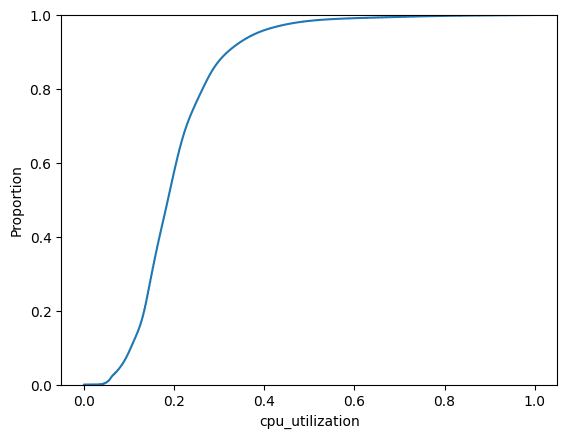

In [10]:
import seaborn as sns

sns.ecdfplot(data=node_df, x="cpu_utilization")

/var/folders/35/6xjjlvhn18q8lhz533ycffnr0000gp/T/ipykernel_41757/942059220.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.ecdfplot(ms_df.groupby(['timestamp', 'msname']).sum().reset_index(), x="cpu_utilization")


<AxesSubplot: xlabel='cpu_utilization', ylabel='Proportion'>

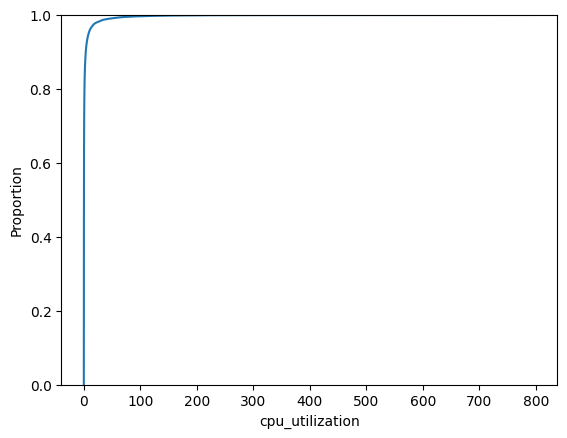

In [18]:
sns.ecdfplot(ms_df.groupby(['timestamp', 'msname']).sum().reset_index(), x="cpu_utilization")

In [141]:
ms_df.groupby(['timestamp', 'nodeid']).sum()

/var/folders/35/6xjjlvhn18q8lhz533ycffnr0000gp/T/ipykernel_41757/4088893861.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ms_df.groupby(['timestamp', 'nodeid']).sum()


cpu_utilization  memory_utilization
timestamp nodeid                                         
0         NODE_10            1.935462            6.292795
          NODE_1000          3.521370           13.608631
          NODE_10002         0.555958            1.220783
          NODE_10003         1.191124            4.311361
          NODE_10004         4.698438           15.416209
...                               ...                 ...
1740000   NODE_9995          1.848071            5.791797
          NODE_9996          6.757144           17.247150
          NODE_9997          4.758594           16.306116
          NODE_9998          1.525989            6.813183
          NODE_9999          2.186712           11.947394

[944171 rows x 2 columns]

In [16]:
"State": {"NumOfNodes": 3, "NumOfSvc": 3, "NodesToSvc": [[5, 0, 0], [5, 0, 0], [2, 2, 1]], "NodeCaps": [100, 100, 100], "SvcLoads": [180, 0, 0]}, 

"Hosts": [{"name": "node0", "cap": 100}, {"name": "node1", "cap": 100}, {"name": "node2", "cap": 100}],

"Tenants": [{"name": "svc0", "load": 180, "fshareload": 240.0}, {"name": "svc1", "load": 0, "fshareload": 40.0}, {"name": "svc2", "load": 0, "fshareload": 20.0}]

"Workers": [{"name": "svc0-node0-0", "host": "node0", "tenant": "svc0"}, {"name": "svc0-node0-1", "host": "node0", "tenant": "svc0"}, {"name": "svc0-node0-2", "host": "node0", "tenant": "svc0"}, {"name": "svc0-node0-3", "host": "node0", "tenant": "svc0"}, {"name": "svc0-node0-4", "host": "node0", "tenant": "svc0"}, {"name": "svc0-node1-0", "host": "node1", "tenant": "svc0"}, {"name": "svc0-node1-1", "host": "node1", "tenant": "svc0"}, {"name": "svc0-node1-2", "host": "node1", "tenant": "svc0"}, {"name": "svc0-node1-3", "host": "node1", "tenant": "svc0"}, {"name": "svc0-node1-4", "host": "node1", "tenant": "svc0"}, {"name": "svc0-node2-0", "host": "node2", "tenant": "svc0"}, {"name": "svc0-node2-1", "host": "node2", "tenant": "svc0"}, {"name": "svc1-node2-0", "host": "node2", "tenant": "svc1"}, {"name": "svc1-node2-1", "host": "node2", "tenant": "svc1"}, {"name": "svc2-node2-0", "host": "node2", "tenant": "svc2"}]


30

In [142]:
# get a timestamp of the ms_df
ms_df_0 = ms_df[ms_df['timestamp'] == 0].copy()
ms_df_0

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
1897293,0,MS_10845,MS_10845_POD_3,NODE_20712,0.093240,0.516560
6306961,0,MS_56120,MS_56120_POD_191,NODE_10480,0.169800,0.772035
11765565,0,MS_38052,MS_38052_POD_89,NODE_33773,0.030250,0.740018
11765564,0,MS_52269,MS_52269_POD_9,NODE_25766,0.518512,0.802101
6306941,0,MS_65234,MS_65234_POD_3,NODE_19469,0.037250,0.385601
...,...,...,...,...,...,...
5142120,0,MS_57025,MS_57025_POD_1861,NODE_23646,0.132938,0.477051
1693954,0,MS_13729,MS_13729_POD_998,NODE_46069,0.122580,0.733891
13325203,0,MS_3236,MS_3236_POD_31,NODE_28726,0.162271,0.742758
237031,0,MS_40747,MS_40747_POD_1,NODE_41748,0.049729,0.576809


In [38]:
ms_df_0[ms_df_0["msinstanceid"] == "MS_6945_POD_9729"]["nodeid"].iloc[0]

'NODE_21388'

In [143]:
ms_df_0 = ms_df_0.drop_duplicates()

In [31]:
ms_df_0.msinstanceid.value_counts()

MS_6945_POD_9477    2
MS_6945_POD_9729    2
MS_10845_POD_3      1
MS_22341_POD_8      1
MS_468_POD_0        1
                   ..
MS_8014_POD_9       1
MS_59851_POD_27     1
MS_10039_POD_53     1
MS_14259_POD_74     1
MS_44527_POD_12     1
Name: msinstanceid, Length: 466766, dtype: int64

In [144]:
ms_df_0.groupby("msinstanceid")

In [43]:
# Drop duplicate msinstanceid rows (keeping the first)
unique_instances = ms_df_0.drop_duplicates(subset="msinstanceid")

# Now iterate efficiently
workers = [
    {
        "name": row["msinstanceid"],
        "host": row["nodeid"],
        "tenant": row["msname"]
    }
    for _, row in unique_instances.iterrows()
]

print(f"Done generating {len(workers)} workers")

Done generating 466766 workers


In [45]:
unique_instances

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
1897293,0,MS_10845,MS_10845_POD_3,NODE_20712,0.093240,0.516560
6306961,0,MS_56120,MS_56120_POD_191,NODE_10480,0.169800,0.772035
11765565,0,MS_38052,MS_38052_POD_89,NODE_33773,0.030250,0.740018
11765564,0,MS_52269,MS_52269_POD_9,NODE_25766,0.518512,0.802101
6306941,0,MS_65234,MS_65234_POD_3,NODE_19469,0.037250,0.385601
...,...,...,...,...,...,...
5142120,0,MS_57025,MS_57025_POD_1861,NODE_23646,0.132938,0.477051
1693954,0,MS_13729,MS_13729_POD_998,NODE_46069,0.122580,0.733891
13325203,0,MS_3236,MS_3236_POD_31,NODE_28726,0.162271,0.742758
237031,0,MS_40747,MS_40747_POD_1,NODE_41748,0.049729,0.576809


In [145]:
def get_state(ms_df_: pd.DataFrame) -> tuple[list[dict], list[dict], list[dict]]:

    def get_node_cap(node_id: str) -> int:
        return 100
    def get_ms_load(msname: str) -> int:
        return 0

    node_ids = ms_df_.nodeid.unique()
    hosts = []
    n_hosts = len(node_ids)
    for i, node_id in enumerate(node_ids):
        hosts.append({
            "name": node_id,
            "cap": get_node_cap(node_id)
        })
        print(f"Done host {i}/{n_hosts}")
    
    msnames = ms_df_.msname.unique()
    tenants = {}
    n_tenants = len(msnames)
    for i, msname in enumerate(msnames):
        tenants[msname] = {
            "name": msname,
            "load": get_ms_load(msname),
            "fshareload": 0
        }
        print(f"Done tenant {i}/{n_tenants}")

    # Drop duplicate msinstanceid rows (keeping the first)
    unique_instances = ms_df_0.drop_duplicates(subset="msinstanceid")
    # Now iterate efficiently
    workers = [
        {
            "name": row["msinstanceid"],
            "host": row["nodeid"],
            "tenant": row["msname"]
        }
        for _, row in unique_instances.iterrows()
    ]
    print(f"Done generating {len(workers)} workers")

    # calculate the fshareload for each tenant
    # fshareload_of_tenant_t = sum(fshareload_of_worker_w when w.tenant == t)
    # fshareload_of_worker_w = host.cap / number of workers on host
    for i, host in enumerate(hosts):
        workers_on_host = [worker for worker in workers if worker["host"] == host["name"]]
        
        n_workers_on_host = len(workers_on_host)
        
        for worker in workers_on_host:
            tenant_name = worker["tenant"]
            tenants[tenant_name]["fshareload"] += host["cap"] / n_workers_on_host
            
        print(f"Done fshareload {i}/{n_hosts}")
        
    return hosts, list(tenants.values()), workers

get_state(ms_df_0)

Done host 0/31475
Done host 1/31475
Done host 2/31475
Done host 3/31475
Done host 4/31475
Done host 5/31475
Done host 6/31475
Done host 7/31475
Done host 8/31475
Done host 9/31475
Done host 10/31475
Done host 11/31475
Done host 12/31475
Done host 13/31475
Done host 14/31475
Done host 15/31475
Done host 16/31475
Done host 17/31475
Done host 18/31475
Done host 19/31475
Done host 20/31475
Done host 21/31475
Done host 22/31475
Done host 23/31475
Done host 24/31475
Done host 25/31475
Done host 26/31475
Done host 27/31475
Done host 28/31475
Done host 29/31475
Done host 30/31475
Done host 31/31475
Done host 32/31475
Done host 33/31475
Done host 34/31475
Done host 35/31475
Done host 36/31475
Done host 37/31475
Done host 38/31475
Done host 39/31475
Done host 40/31475
Done host 41/31475
Done host 42/31475
Done host 43/31475
Done host 44/31475
Done host 45/31475
Done host 46/31475
Done host 47/31475
Done host 48/31475
Done host 49/31475
Done host 50/31475
Done host 51/31475
Done host 52/31475
Don

KeyboardInterrupt: 

In [361]:
import random

def get_state(ms_df_: pd.DataFrame) -> tuple[list[dict], list[dict], list[dict]]:
    
    unique_instances = ms_df_.drop_duplicates(subset="msinstanceid").copy()
    node_msinstance_count = unique_instances.groupby("nodeid").count()["msinstanceid"].to_dict()
    
    def get_node_cap(node_id: str) -> int:
        return node_msinstance_count[node_id] * 10

    def get_ms_load(msname: str, fshare: float) -> int:
        return (np.random.exponential(scale=80) / 100.0) * fshare
        # return (random.randint(60, 120) / 100.0) * fshare

    # Build host info
    node_caps = {node_id: get_node_cap(node_id) for node_id in ms_df_.nodeid.unique()}
    hosts = [{"name": node_id, "cap": cap} for node_id, cap in node_caps.items()]
    print(f"Done host {len(hosts)}/{len(hosts)}")

    # Build tenant info
    msnames = ms_df_.msname.unique()
    tenants = {
        msname: {"name": msname, "load": 0, "fshareload": 0}
        for msname in msnames
    }
    print(f"Done tenant {len(tenants)}/{len(tenants)}")

    # Get one row per msinstanceid
    workers = unique_instances[["msinstanceid", "nodeid", "msname"]].rename(
        columns={"msinstanceid": "name", "nodeid": "host", "msname": "tenant"}
    ).to_dict("records")
    print(f"Done generating {len(workers)} workers")

    # Count number of workers per host
    host_counts = unique_instances["nodeid"].value_counts().to_dict()

    # Assign fshareload to each worker
    unique_instances["worker_share"] = unique_instances["nodeid"].map(
        lambda nid: node_caps[nid] / host_counts[nid]
    )

    # Group by tenant and sum worker shares
    fshare_per_tenant = unique_instances.groupby("msname")["worker_share"].sum()

    for tenant_name, fshare in fshare_per_tenant.items():
        tenants[tenant_name]["fshareload"] = fshare
        tenants[tenant_name]["load"] = get_ms_load(tenant_name, fshare)

    print("Done fshareload")

    return hosts, list(tenants.values()), workers

hosts, tenants, workers = get_state(ms_df_0)

Done host 31475/31475
Done tenant 28143/28143


Done generating 466766 workers
Done fshareload


In [362]:
tenants_df = pd.DataFrame(tenants)
tenants_df

,name,load,fshareload
0,MS_10845,21.763231,60.0
1,MS_56120,3202.742213,3040.0
2,MS_38052,2078.750998,900.0
3,MS_52269,60.154958,320.0
4,MS_65234,86.431503,90.0
...,...,...,...
28138,MS_35294,24.407831,10.0
28139,MS_15894,7.780156,10.0
28140,MS_47693,8.445977,10.0
28141,MS_11250,38.572086,10.0


In [363]:
import json
with open("alibaba_cluster_state_n80.json", "w") as f:
    json.dump([
        hosts,
        tenants,
        workers
    ], f, indent=4)

In [326]:
state = 2

In [327]:
with open(f"from_cloudlab/alibaba/alibaba_cluster_state{state}.json", "r") as f:
    data = json.loads(f.read())
    hosts, tenants, workers = data[0], data[1], data[2]

In [328]:
tenant_loads = {t["name"]: t["load"] for t in tenants}
tenant_loads

{'MS_10845': 67.8,
 'MS_56120': 2219.2,
 'MS_38052': 693.0,
 'MS_52269': 364.79999999999995,
 'MS_65234': 62.099999999999994,
 'MS_10489': 15035.0,
 'MS_14545': 1091.2,
 'MS_15187': 967.5,
 'MS_70353': 131.6,
 'MS_1743': 706.8,
 'MS_4252': 800.0,
 'MS_37860': 136.0,
 'MS_56317': 113.99999999999999,
 'MS_1017': 139.5,
 'MS_68393': 253.00000000000003,
 'MS_35322': 8810.2,
 'MS_35701': 79.2,
 'MS_67216': 1558.0,
 'MS_24846': 4879.0,
 'MS_69187': 96.0,
 'MS_52093': 49.6,
 'MS_3801': 844.6,
 'MS_7826': 481.4,
 'MS_52789': 186.0,
 'MS_42557': 3801.9,
 'MS_10120': 195.8,
 'MS_62821': 96.0,
 'MS_24930': 3720.2000000000003,
 'MS_11560': 155.2,
 'MS_51138': 18.400000000000002,
 'MS_19349': 6076.2,
 'MS_72245': 448.00000000000006,
 'MS_39272': 558.0,
 'MS_60468': 1036.6,
 'MS_68570': 926.5000000000001,
 'MS_49499': 6751.8,
 'MS_40814': 4080.0000000000005,
 'MS_24472': 2280.0,
 'MS_37433': 133.20000000000002,
 'MS_3121': 1513.2,
 'MS_48931': 5065.4,
 'MS_45688': 64.80000000000001,
 'MS_43157': 163

In [329]:
with open(f"from_cloudlab/alibaba/alibaba_cluster_state{state}.json_output", "r") as f:
    data = json.load(f)

data

global_result = data['result']
global_result

global_result_ms_instance_utils = {msinstance: util for ms, msinstanceutils in global_result.items() for msinstance, util in msinstanceutils.items()}
global_result_ms_instance_utils

alibaba_topo = unique_instances
alibaba_topo['global_util'] = alibaba_topo['msinstanceid'].apply(lambda msinstance: global_result_ms_instance_utils[msinstance])
# alibaba_topo

In [330]:
with open(f"from_cloudlab/alibaba/alibaba_cluster_state{state}.json_local_opt_output", "r") as f:
    data = json.load(f)

data

local_result = data['result']
local_result

local_result_ms_instance_utils = {msinstance: util for ms, msinstanceutils in local_result.items() for msinstance, util in msinstanceutils.items()}
local_result_ms_instance_utils

alibaba_topo['local_util'] = alibaba_topo['msinstanceid'].apply(lambda msinstance: local_result_ms_instance_utils[msinstance])
alibaba_topo

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization,global_util,local_util
1897293,0,MS_10845,MS_10845_POD_3,NODE_20712,0.093240,0.516560,66.1,9.707803
6306961,0,MS_56120,MS_56120_POD_191,NODE_10480,0.169800,0.772035,0.0,10.015586
11765565,0,MS_38052,MS_38052_POD_89,NODE_33773,0.030250,0.740018,0.0,10.468484
11765564,0,MS_52269,MS_52269_POD_9,NODE_25766,0.518512,0.802101,0.0,10.393475
6306941,0,MS_65234,MS_65234_POD_3,NODE_19469,0.037250,0.385601,0.0,5.983251
...,...,...,...,...,...,...,...,...
5142120,0,MS_57025,MS_57025_POD_1861,NODE_23646,0.132938,0.477051,0.0,9.625591
1693954,0,MS_13729,MS_13729_POD_998,NODE_46069,0.122580,0.733891,120.0,10.164761
13325203,0,MS_3236,MS_3236_POD_31,NODE_28726,0.162271,0.742758,0.0,8.849227
237031,0,MS_40747,MS_40747_POD_1,NODE_41748,0.049729,0.576809,0.0,6.519030


In [345]:
alibaba_node_df = alibaba_topo.groupby('nodeid').agg({'global_util': 'sum', 'local_util': 'sum'}).reset_index()
alibaba_node_df["cap"] = alibaba_node_df["nodeid"].apply(lambda nodeid: node_caps[nodeid])
alibaba_node_df
gu = alibaba_node_df["global_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
lu = alibaba_node_df["local_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
(gu - lu) / lu * 100

4.626516265286933

In [331]:
alibaba_ms_df = alibaba_topo.groupby('msname').agg({'global_util': 'sum', 'local_util': 'sum'}).reset_index()
alibaba_ms_df
alibaba_ms_df[(alibaba_ms_df["global_util"] - alibaba_ms_df["local_util"]) > .1]

,msname,global_util,local_util
3,MS_10003,309.4,298.246707
5,MS_10007,20.6,19.628884
7,MS_1001,44.4,41.989951
9,MS_10015,58.5,54.762632
12,MS_10025,680.4,650.237134
...,...,...,...
28136,MS_9988,23.6,22.436678
28137,MS_9989,11.6,10.682543
28138,MS_9991,102.0,95.601411
28140,MS_9994,83.2,81.463082


(0.5, 1.0)

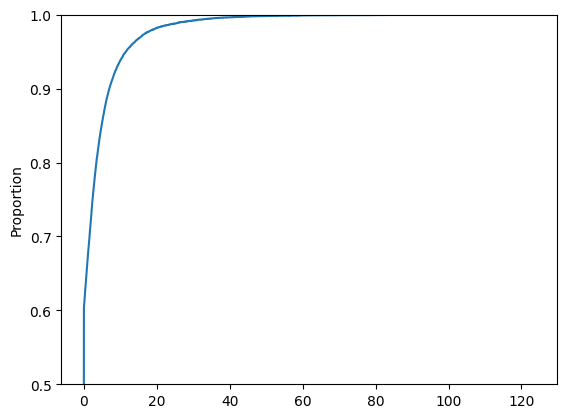

In [348]:

sns.ecdfplot((alibaba_ms_df["global_util"] - alibaba_ms_df["local_util"]) / alibaba_ms_df["local_util"] * 100)
plt.ylim(0.5, 1)

In [ ]:
sns.ecdfplot((alibaba_ms_df["global_util"] - alibaba_ms_df["local_util"]) / alibaba_ms_df["local_util"] * 100)

3694 / 28143


28143 

In [334]:
alibaba_ms_df["improvement"] = (alibaba_ms_df["global_util"] - alibaba_ms_df["local_util"]) / alibaba_ms_df["local_util"] * 100
alibaba_ms_df

,msname,global_util,local_util,improvement
0,MS_10,21.0,21.000000,0.000000e+00
1,MS_100,11.4,11.400000,1.558208e-14
2,MS_10000,240.0,240.000000,-2.368476e-14
3,MS_10003,309.4,298.246707,3.739620e+00
4,MS_10006,11.4,11.400000,-4.053740e-09
...,...,...,...,...
28138,MS_9991,102.0,95.601411,6.692986e+00
28139,MS_9992,38.5,38.500000,0.000000e+00
28140,MS_9994,83.2,81.463082,2.132154e+00
28141,MS_9995,22.0,22.000000,0.000000e+00


In [335]:
alibaba_ms_df["demand"] = alibaba_ms_df["msname"].apply(lambda n: tenant_loads[n])
alibaba_ms_df

,msname,global_util,local_util,improvement,demand
0,MS_10,21.0,21.000000,0.000000e+00,21.0
1,MS_100,11.4,11.400000,1.558208e-14,11.4
2,MS_10000,240.0,240.000000,-2.368476e-14,240.0
3,MS_10003,309.4,298.246707,3.739620e+00,309.4
4,MS_10006,11.4,11.400000,-4.053740e-09,11.4
...,...,...,...,...,...
28138,MS_9991,102.0,95.601411,6.692986e+00,102.0
28139,MS_9992,38.5,38.500000,0.000000e+00,38.5
28140,MS_9994,83.2,81.463082,2.132154e+00,83.2
28141,MS_9995,22.0,22.000000,0.000000e+00,22.0


In [336]:
print(f'Global doesn\'t meet demand in {(len(alibaba_ms_df[(alibaba_ms_df["demand"] - alibaba_ms_df["global_util"]) < 0.01]) / len(alibaba_ms_df) * 100):.2f}% of microservices')
print(f'Local doesn\'t meet demand in {(len(alibaba_ms_df[(alibaba_ms_df["demand"] - alibaba_ms_df["local_util"]) < 0.01]) / len(alibaba_ms_df) * 100):.2f}% of microservices')

Global doesn't meet demand in 99.89% of microservices
Local doesn't meet demand in 60.25% of microservices


In [337]:
demand_not_met_local = set(alibaba_ms_df[(alibaba_ms_df["demand"] - alibaba_ms_df["local_util"]) > 0.001]["msname"])
demand_met_global = set(alibaba_ms_df[(alibaba_ms_df["demand"] - alibaba_ms_df["global_util"]) < 0.001]["msname"])
len(demand_met_global.intersection(demand_not_met_local)) / len(demand_not_met_local) * 100

99.71476958730725

In [338]:
demand_not_met_local

{'MS_47031',
 'MS_62543',
 'MS_26172',
 'MS_22905',
 'MS_23374',
 'MS_51846',
 'MS_30053',
 'MS_25159',
 'MS_26855',
 'MS_43230',
 'MS_27372',
 'MS_58616',
 'MS_32130',
 'MS_59348',
 'MS_56038',
 'MS_46212',
 'MS_49094',
 'MS_61651',
 'MS_29623',
 'MS_63525',
 'MS_28190',
 'MS_14481',
 'MS_45593',
 'MS_6025',
 'MS_35644',
 'MS_31195',
 'MS_15104',
 'MS_60680',
 'MS_51903',
 'MS_54671',
 'MS_39893',
 'MS_43453',
 'MS_6402',
 'MS_65961',
 'MS_13899',
 'MS_69574',
 'MS_23491',
 'MS_8478',
 'MS_48878',
 'MS_54760',
 'MS_11945',
 'MS_19652',
 'MS_60716',
 'MS_8358',
 'MS_63567',
 'MS_20176',
 'MS_29960',
 'MS_9028',
 'MS_23249',
 'MS_48664',
 'MS_48011',
 'MS_38026',
 'MS_59419',
 'MS_63343',
 'MS_31546',
 'MS_17602',
 'MS_10535',
 'MS_72324',
 'MS_40575',
 'MS_53538',
 'MS_17007',
 'MS_31105',
 'MS_27852',
 'MS_53690',
 'MS_6095',
 'MS_13759',
 'MS_11304',
 'MS_64095',
 'MS_32465',
 'MS_14452',
 'MS_19083',
 'MS_50659',
 'MS_36058',
 'MS_35701',
 'MS_30984',
 'MS_64939',
 'MS_66964',
 'MS_

In [339]:
alibaba_ms_df.sort_values(by=['improvement'], ascending=False, inplace=True)
alibaba_ms_df.head(100)

,msname,global_util,local_util,improvement,demand
23410,MS_65008,213.6,95.509978,123.641554,213.6
22856,MS_63738,39.2,18.328741,113.871753,39.2
24282,MS_67034,278.4,133.868727,107.964927,278.4
24791,MS_68245,41.6,20.118919,106.770553,41.6
14572,MS_44196,59.0,29.891527,97.380345,59.0
...,...,...,...,...,...
9044,MS_31053,44.4,31.488970,41.001753,44.4
9412,MS_31940,28.2,20.014953,40.894658,28.2
10482,MS_34436,21.2,15.047619,40.886076,21.2
7042,MS_26526,29.2,20.757895,40.669371,29.2


In [340]:
alibaba_ms_df[alibaba_ms_df["improvement"] > 5]

,msname,global_util,local_util,improvement,demand
23410,MS_65008,213.6,95.509978,123.641554,213.6
22856,MS_63738,39.2,18.328741,113.871753,39.2
24282,MS_67034,278.4,133.868727,107.964927,278.4
24791,MS_68245,41.6,20.118919,106.770553,41.6
14572,MS_44196,59.0,29.891527,97.380345,59.0
...,...,...,...,...,...
23138,MS_64394,3700.0,3523.590217,5.006535,3700.0
12516,MS_39179,17.6,16.761069,5.005237,17.6
7142,MS_26761,180.0,171.420084,5.005199,180.0
15188,MS_45664,904.0,860.937300,5.001839,904.0


In [350]:
alibaba_ms_df["local_util"] / alibaba_ms_df["demand"]

23410    0.447144
22856    0.467570
24282    0.480850
24791    0.483628
14572    0.506636
           ...   
20584    1.000000
8910     1.000000
10995    1.000000
24891    1.000000
15485    1.000000
Length: 28143, dtype: float64

In [351]:
alibaba_ms_df["global_util"] / alibaba_ms_df["demand"]

23410    1.0
22856    1.0
24282    1.0
24791    1.0
14572    1.0
        ... 
20584    1.0
8910     1.0
10995    1.0
24891    1.0
15485    1.0
Length: 28143, dtype: float64

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


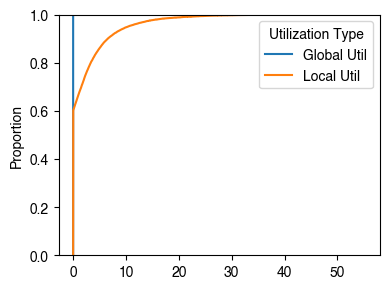

In [360]:
from matplotlib import pyplot as plt
_, ax = plt.subplots(figsize=(4, 3))
sns.ecdfplot(ax=ax, data=(alibaba_ms_df["demand"] - alibaba_ms_df["global_util"]) / alibaba_ms_df["demand"] * 100, label="Global Util")
sns.ecdfplot(ax=ax, data=(alibaba_ms_df["demand"] - alibaba_ms_df["local_util"]) / alibaba_ms_df["demand"] * 100, label="Local Util")
# ax.legend_.show()

ax.legend = ax.legend(title="Utilization Type")

plt.tight_layout()
savefig("alibaba_ms_demand_cdf")

In [218]:
unique_instances = ms_df_0.drop_duplicates(subset="msinstanceid").copy()
node_msinstance_counts = unique_instances.groupby("nodeid").count()["msinstanceid"].to_dict()
node_caps = {node: node_msinstance_count * 10.0 for node, node_msinstance_count in node_msinstance_counts.items()}

In [219]:
alibaba_node_df = alibaba_topo.groupby('nodeid').agg({'global_util': 'sum', 'local_util': 'sum'}).reset_index()
alibaba_node_df["cap"] = alibaba_node_df["nodeid"].apply(lambda nodeid: node_caps[nodeid])
alibaba_node_df
gu = alibaba_node_df["global_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
lu = alibaba_node_df["local_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
(gu - lu) / lu * 100

,nodeid,global_util,local_util,cap
0,NODE_10,150.0,101.121959,150.0
1,NODE_1000,0.0,147.519133,210.0
2,NODE_10002,30.0,26.195191,30.0
3,NODE_10003,0.0,90.000000,90.0
4,NODE_10004,157.1,145.682664,240.0
...,...,...,...,...
31470,NODE_9995,82.4,106.975693,110.0
31471,NODE_9996,270.0,153.453911,270.0
31472,NODE_9997,260.0,147.795690,260.0
31473,NODE_9998,130.0,130.000000,130.0


In [223]:
alibaba_node_df["local_util"] = alibaba_node_df[['cap', 'local_util']].min(axis=1)

In [ ]:
unique_instances = ms_df_0.drop_duplicates(subset="msinstanceid").copy()
node_msinstance_count = unique_instances.groupby("nodeid").count()["msinstanceid"].to_dict()
node_msinstance_count

In [342]:
gu = alibaba_node_df["global_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
lu = alibaba_node_df["local_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
(gu - lu) / lu * 100
gu

3543479.2999998056

In [343]:
lu = alibaba_node_df["local_util"].sum() # / (len(alibaba_node_df["global_util"]) * 100)
lu

3467123.476728452

In [344]:
(gu - lu) / lu * 100

2.2022816257874505

In [201]:
alibaba_node_df

,nodeid,global_util,local_util
0,NODE_10,150.0,100.000000
1,NODE_1000,0.0,100.000000
2,NODE_10002,30.0,26.195191
3,NODE_10003,0.0,93.414308
4,NODE_10004,157.1,100.000000
...,...,...,...
31470,NODE_9995,82.4,100.000000
31471,NODE_9996,270.0,100.000000
31472,NODE_9997,260.0,100.000000
31473,NODE_9998,130.0,100.000000


In [214]:
(2.2/100) * 31475

692.45

In [9]:
len(ms_df["msinstanceid"].unique())

467613

In [10]:
len(ms_df["msname"].unique())

28159

In [18]:
ms_df.loc[ms_df["msinstanceid"] == "MS_39923_POD_362"]

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
2096280,0,MS_39923,MS_39923_POD_362,NODE_13658,0.203304,0.796379
1710402,60000,MS_39923,MS_39923_POD_362,NODE_13658,0.202026,0.795256
2106914,120000,MS_39923,MS_39923_POD_362,NODE_13658,0.187423,0.795708
6293510,180000,MS_39923,MS_39923_POD_362,NODE_13658,0.217661,0.795965
2092185,240000,MS_39923,MS_39923_POD_362,NODE_13658,0.189341,0.796181
2100988,300000,MS_39923,MS_39923_POD_362,NODE_13658,0.186686,0.796189
6296433,360000,MS_39923,MS_39923_POD_362,NODE_13658,0.189243,0.795314
6292074,420000,MS_39923,MS_39923_POD_362,NODE_13658,0.200256,0.795721
2090932,480000,MS_39923,MS_39923_POD_362,NODE_13658,0.211220,0.795874
6298977,540000,MS_39923,MS_39923_POD_362,NODE_13658,0.197601,0.796179


In [11]:
ms_df_all = ms_df
ms_df = ms_df[["msname", "msinstanceid", "nodeid"]]
ms_df

,msname,msinstanceid,nodeid
1897293,MS_10845,MS_10845_POD_3,NODE_20712
6306961,MS_56120,MS_56120_POD_191,NODE_10480
11765565,MS_38052,MS_38052_POD_89,NODE_33773
11765564,MS_52269,MS_52269_POD_9,NODE_25766
6306941,MS_65234,MS_65234_POD_3,NODE_19469
...,...,...,...
10490540,MS_1947,MS_1947_POD_11,NODE_2537
4380397,MS_69117,MS_69117_POD_114,NODE_40326
2104494,MS_39923,MS_39923_POD_362,NODE_13658
11234990,MS_64207,MS_64207_POD_9,NODE_4859


In [12]:
ms_df = ms_df.drop_duplicates()

In [13]:
len(ms_df)

467615

In [14]:
ms_instance_series = ms_df["msinstanceid"]
ms_instance_series_unique = ms_df["msinstanceid"].unique()

In [16]:
len(ms_instance_series), len(ms_instance_series_unique)

(467615, 467613)

In [17]:
ms_instance_series.value_counts()

MS_6945_POD_9477     2
MS_6945_POD_9729     2
MS_10845_POD_3       1
MS_13752_POD_22      1
MS_37555_POD_1326    1
                    ..
MS_71672_POD_2       1
MS_49648_POD_42      1
MS_57157_POD_519     1
MS_68948_POD_2201    1
MS_37056_POD_26      1
Name: msinstanceid, Length: 467613, dtype: int64

In [20]:
ms_df_all[ms_df_all["msinstanceid"] == "MS_6945_POD_9729"]

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
5774618,0,MS_6945,MS_6945_POD_9729,NODE_21388,0.002250,0.124208
11140491,0,MS_6945,MS_6945_POD_9729,NODE_31027,0.016333,0.087728
1059029,60000,MS_6945,MS_6945_POD_9729,NODE_31027,0.017250,0.087762
5775083,60000,MS_6945,MS_6945_POD_9729,NODE_21388,0.000990,0.124208
5781841,120000,MS_6945,MS_6945_POD_9729,NODE_21388,0.001080,0.124208
11137905,120000,MS_6945,MS_6945_POD_9729,NODE_31027,0.016917,0.087968
5778505,180000,MS_6945,MS_6945_POD_9729,NODE_31027,0.018500,0.087703
5777891,180000,MS_6945,MS_6945_POD_9729,NODE_21388,0.001080,0.124208
5777293,240000,MS_6945,MS_6945_POD_9729,NODE_31027,0.016917,0.087975
5776483,240000,MS_6945,MS_6945_POD_9729,NODE_21388,0.000990,0.124208


In [25]:
ms_df.sort_values(by=['nodeid', 'msname'])

,msname,msinstanceid,nodeid
12378243,MS_11733,MS_11733_POD_27,NODE_10
4325704,MS_15097,MS_15097_POD_152,NODE_10
6307417,MS_2557,MS_2557_POD_52,NODE_10
3836418,MS_2562,MS_2562_POD_104,NODE_10
7255674,MS_27525,MS_27525_POD_4,NODE_10
...,...,...,...
7120781,MS_63360,MS_63360_POD_23,NODE_9999
5670399,MS_66711,MS_66711_POD_3461,NODE_9999
8245807,MS_69665,MS_69665_POD_560,NODE_9999
3504204,MS_69665,MS_69665_POD_541,NODE_9999


In [28]:
ms_df[ms_df["nodeid"] == "NODE_10"]

,msname,msinstanceid,nodeid
6307417,MS_2557,MS_2557_POD_52,NODE_10
8749457,MS_45705,MS_45705_POD_31,NODE_10
3415859,MS_72474,MS_72474_POD_72,NODE_10
11486735,MS_65402,MS_65402_POD_298,NODE_10
7255674,MS_27525,MS_27525_POD_4,NODE_10
693295,MS_9508,MS_9508_POD_30,NODE_10
12378243,MS_11733,MS_11733_POD_27,NODE_10
7884792,MS_49840,MS_49840_POD_364,NODE_10
3836418,MS_2562,MS_2562_POD_104,NODE_10
13759039,MS_65402,MS_65402_POD_282,NODE_10


In [48]:
def get_scenario1():
    ms_names = ms_df["msname"].unique()

    with open("data/scenario1.txt", "w") as f:
        for ms1 in ms_names:
            n1 = set(ms_df[ms_df["msname"] == ms1]["nodeid"].unique())
            for ms2 in ms_names:
                if ms1 != ms2:
                    n2 = set(ms_df[ms_df["msname"] == ms2]["nodeid"].unique())
                    
                    n12 = n1.intersection(n2)
                    if len(n12) > 0 and len(n12) < len(n1):
                        f.write(f"{ms1}\n{ms2}\n{n12}\n{n1}\n{n2}\n")

In [47]:
with open("data/scenario1.txt", "w") as f:
    f.write(f"{ms1}\n{ms2}\n{n12}\n{n1}\n{n2}\n")

In [49]:
get_scenario1()

KeyboardInterrupt: 

In [45]:
ms1, ms2, n12, n1, n2

('MS_10845',
 'MS_6298',
 {'NODE_20712', 'NODE_37722'},
 {'NODE_19678',
  'NODE_20712',
  'NODE_22484',
  'NODE_35520',
  'NODE_37722',
  'NODE_40080'},
 {'NODE_1000',
  'NODE_10004',
  'NODE_10196',
  'NODE_10215',
  'NODE_10218',
  'NODE_10281',
  'NODE_10297',
  'NODE_10310',
  'NODE_10344',
  'NODE_10369',
  'NODE_10397',
  'NODE_10423',
  'NODE_10437',
  'NODE_10455',
  'NODE_10472',
  'NODE_10477',
  'NODE_10549',
  'NODE_10575',
  'NODE_10598',
  'NODE_10822',
  'NODE_10867',
  'NODE_11047',
  'NODE_11063',
  'NODE_11121',
  'NODE_11145',
  'NODE_11173',
  'NODE_1119',
  'NODE_11264',
  'NODE_11334',
  'NODE_11338',
  'NODE_11469',
  'NODE_11540',
  'NODE_11575',
  'NODE_11733',
  'NODE_11751',
  'NODE_11752',
  'NODE_11817',
  'NODE_11884',
  'NODE_120',
  'NODE_12059',
  'NODE_12196',
  'NODE_12201',
  'NODE_12210',
  'NODE_12257',
  'NODE_12267',
  'NODE_1249',
  'NODE_12524',
  'NODE_12598',
  'NODE_12663',
  'NODE_12812',
  'NODE_12905',
  'NODE_13193',
  'NODE_1320',
  'NO

In [ ]:
MS_48931
MS_68431
{'NODE_7314', 'NODE_28896', 'NODE_24886', 'NODE_14289'}
{'NODE_18379', 'NODE_41900', 'NODE_1345', 'NODE_15354', 'NODE_11471', 'NODE_40915', 'NODE_36442', 'NODE_38244', 'NODE_216', 'NODE_35079', 'NODE_41026', 'NODE_39256', 'NODE_35384', 'NODE_37126', 'NODE_10538', 'NODE_24670', 'NODE_6650', 'NODE_46842', 'NODE_2328', 'NODE_2264', 'NODE_16614', 'NODE_8390', 'NODE_40250', 'NODE_11832', 'NODE_27609', 'NODE_38579', 'NODE_36936', 'NODE_21930', 'NODE_38425', 'NODE_6874', 'NODE_11894', 'NODE_47168', 'NODE_803', 'NODE_37486', 'NODE_7205', 'NODE_25495', 'NODE_7008', 'NODE_13074', 'NODE_4485', 'NODE_19846', 'NODE_11526', 'NODE_29213', 'NODE_24005', 'NODE_7165', 'NODE_29127', 'NODE_9775', 'NODE_16058', 'NODE_25445', 'NODE_21235', 'NODE_36317', 'NODE_16452', 'NODE_43327', 'NODE_29234', 'NODE_24127', 'NODE_14716', 'NODE_8088', 'NODE_38025', 'NODE_35418', 'NODE_22232', 'NODE_26355', 'NODE_42337', 'NODE_35488', 'NODE_37333', 'NODE_41706', 'NODE_39963', 'NODE_46381', 'NODE_8331', 'NODE_11145', 'NODE_30530', 'NODE_9082', 'NODE_37250', 'NODE_13435', 'NODE_28651', 'NODE_10714', 'NODE_1286', 'NODE_7880', 'NODE_7617', 'NODE_7153', 'NODE_36055', 'NODE_41504', 'NODE_37413', 'NODE_20678', 'NODE_32290', 'NODE_30241', 'NODE_6721', 'NODE_30493', 'NODE_5616', 'NODE_21254', 'NODE_30987', 'NODE_36519', 'NODE_34338', 'NODE_38812', 'NODE_17153', 'NODE_12356', 'NODE_35056', 'NODE_6587', 'NODE_44780', 'NODE_43675', 'NODE_37035', 'NODE_41326', 'NODE_32477', 'NODE_16064', 'NODE_18766', 'NODE_27691', 'NODE_33575', 'NODE_20290', 'NODE_40074', 'NODE_36228', 'NODE_31303', 'NODE_19384', 'NODE_37328', 'NODE_22041', 'NODE_24268', 'NODE_32317', 'NODE_30548', 'NODE_33958', 'NODE_4233', 'NODE_3186', 'NODE_23353', 'NODE_14261', 'NODE_20614', 'NODE_42574', 'NODE_37282', 'NODE_29570', 'NODE_15513', 'NODE_28202', 'NODE_41398', 'NODE_35780', 'NODE_17325', 'NODE_26847', 'NODE_41034', 'NODE_39546', 'NODE_30117', 'NODE_14411', 'NODE_38321', 'NODE_34627', 'NODE_2247', 'NODE_1461', 'NODE_11629', 'NODE_43139', 'NODE_13747', 'NODE_24835', 'NODE_38243', 'NODE_6555', 'NODE_16573', 'NODE_10857', 'NODE_8627', 'NODE_24676', 'NODE_32391', 'NODE_15666', 'NODE_23930', 'NODE_29501', 'NODE_13982', 'NODE_5207', 'NODE_37277', 'NODE_46599', 'NODE_21129', 'NODE_34448', 'NODE_23202', 'NODE_5209', 'NODE_33790', 'NODE_30976', 'NODE_46887', 'NODE_17388', 'NODE_25551', 'NODE_32823', 'NODE_31124', 'NODE_10715', 'NODE_8013', 'NODE_4149', 'NODE_19461', 'NODE_22237', 'NODE_28853', 'NODE_5285', 'NODE_35697', 'NODE_45473', 'NODE_43492', 'NODE_1741', 'NODE_36299', 'NODE_23894', 'NODE_2317', 'NODE_10811', 'NODE_29514', 'NODE_7002', 'NODE_41078', 'NODE_7012', 'NODE_18928', 'NODE_44568', 'NODE_16939', 'NODE_40746', 'NODE_9266', 'NODE_16548', 'NODE_45888', 'NODE_4755', 'NODE_34449', 'NODE_40319', 'NODE_29642', 'NODE_9699', 'NODE_17170', 'NODE_33598', 'NODE_35011', 'NODE_36705', 'NODE_14289', 'NODE_44051', 'NODE_19014', 'NODE_3022', 'NODE_69', 'NODE_9769', 'NODE_29734', 'NODE_7304', 'NODE_1705', 'NODE_40279', 'NODE_28953', 'NODE_7631', 'NODE_7314', 'NODE_30226', 'NODE_44416', 'NODE_32521', 'NODE_29544', 'NODE_18616', 'NODE_14424', 'NODE_25311', 'NODE_32099', 'NODE_11687', 'NODE_13881', 'NODE_42966', 'NODE_21339', 'NODE_4281', 'NODE_12041', 'NODE_1141', 'NODE_20204', 'NODE_32012', 'NODE_23435', 'NODE_2950', 'NODE_42947', 'NODE_13061', 'NODE_44793', 'NODE_18086', 'NODE_46130', 'NODE_34231', 'NODE_37124', 'NODE_26306', 'NODE_37494', 'NODE_34583', 'NODE_17180', 'NODE_6571', 'NODE_45288', 'NODE_46785', 'NODE_35023', 'NODE_3277', 'NODE_35351', 'NODE_44747', 'NODE_39991', 'NODE_9874', 'NODE_41462', 'NODE_20583', 'NODE_20739', 'NODE_20208', 'NODE_9940', 'NODE_25919', 'NODE_46352', 'NODE_46829', 'NODE_39624', 'NODE_22088', 'NODE_35069', 'NODE_9112', 'NODE_14714', 'NODE_37691', 'NODE_33407', 'NODE_45168', 'NODE_30925', 'NODE_27421', 'NODE_45513', 'NODE_5968', 'NODE_6324', 'NODE_44848', 'NODE_23015', 'NODE_7209', 'NODE_19501', 'NODE_45987', 'NODE_27817', 'NODE_14802', 'NODE_28871', 'NODE_37210', 'NODE_35266', 'NODE_13591', 'NODE_8020', 'NODE_28602', 'NODE_4661', 'NODE_5849', 'NODE_37678', 'NODE_23116', 'NODE_3195', 'NODE_11', 'NODE_3841', 'NODE_15648', 'NODE_35494', 'NODE_9739', 'NODE_11746', 'NODE_43164', 'NODE_3585', 'NODE_5747', 'NODE_7358', 'NODE_46171', 'NODE_19575', 'NODE_16302', 'NODE_16502', 'NODE_34136', 'NODE_12585', 'NODE_29810', 'NODE_39430', 'NODE_9688', 'NODE_1290', 'NODE_9969', 'NODE_5198', 'NODE_8573', 'NODE_22572', 'NODE_2189', 'NODE_46966', 'NODE_40096', 'NODE_10325', 'NODE_14909', 'NODE_30350', 'NODE_43259', 'NODE_17837', 'NODE_41913', 'NODE_41555', 'NODE_11107', 'NODE_30016', 'NODE_8980', 'NODE_8044', 'NODE_17978', 'NODE_17095', 'NODE_30451', 'NODE_41442', 'NODE_7942', 'NODE_25190', 'NODE_17248', 'NODE_12083', 'NODE_18161', 'NODE_15579', 'NODE_292', 'NODE_22520', 'NODE_2779', 'NODE_26796', 'NODE_36777', 'NODE_29639', 'NODE_4368', 'NODE_1929', 'NODE_36341', 'NODE_5633', 'NODE_42026', 'NODE_3619', 'NODE_26072', 'NODE_37225', 'NODE_42721', 'NODE_27584', 'NODE_43230', 'NODE_19105', 'NODE_46550', 'NODE_41790', 'NODE_8557', 'NODE_15363', 'NODE_29103', 'NODE_24993', 'NODE_21772', 'NODE_34371', 'NODE_2467', 'NODE_20942', 'NODE_41444', 'NODE_38312', 'NODE_27491', 'NODE_43229', 'NODE_21024', 'NODE_10642', 'NODE_10727', 'NODE_35827', 'NODE_44490', 'NODE_18491', 'NODE_34617', 'NODE_29129', 'NODE_36282', 'NODE_34115', 'NODE_8241', 'NODE_19419', 'NODE_9515', 'NODE_40323', 'NODE_24858', 'NODE_1853', 'NODE_30837', 'NODE_2738', 'NODE_7116', 'NODE_26551', 'NODE_27588', 'NODE_16364', 'NODE_25105', 'NODE_32814', 'NODE_20245', 'NODE_46815', 'NODE_22313', 'NODE_5627', 'NODE_33514', 'NODE_9573', 'NODE_33500', 'NODE_41663', 'NODE_4348', 'NODE_31302', 'NODE_39952', 'NODE_42387', 'NODE_32204', 'NODE_8217', 'NODE_1283', 'NODE_27297', 'NODE_21507', 'NODE_36841', 'NODE_9630', 'NODE_21539', 'NODE_33927', 'NODE_23337', 'NODE_7903', 'NODE_36075', 'NODE_11442', 'NODE_36497', 'NODE_42551', 'NODE_10296', 'NODE_33742', 'NODE_4566', 'NODE_28056', 'NODE_483', 'NODE_23572', 'NODE_12571', 'NODE_22165', 'NODE_47240', 'NODE_40913', 'NODE_47029', 'NODE_31268', 'NODE_45975', 'NODE_19549', 'NODE_39849', 'NODE_18', 'NODE_43727', 'NODE_10556', 'NODE_28121', 'NODE_29630', 'NODE_4111', 'NODE_7117', 'NODE_6033', 'NODE_16532', 'NODE_35974', 'NODE_4429', 'NODE_2632', 'NODE_46464', 'NODE_4417', 'NODE_27231', 'NODE_20450', 'NODE_14201', 'NODE_46527', 'NODE_13963', 'NODE_18922', 'NODE_20166', 'NODE_24138', 'NODE_22283', 'NODE_43921', 'NODE_1405', 'NODE_26869', 'NODE_26989', 'NODE_3031', 'NODE_12276', 'NODE_6136', 'NODE_28113', 'NODE_26331', 'NODE_16274', 'NODE_23899', 'NODE_17607', 'NODE_19589', 'NODE_25498', 'NODE_2577', 'NODE_22290', 'NODE_36077', 'NODE_12486', 'NODE_33336', 'NODE_16075', 'NODE_20706', 'NODE_12168', 'NODE_9256', 'NODE_2663', 'NODE_46910', 'NODE_23647', 'NODE_3803', 'NODE_2550', 'NODE_26041', 'NODE_32429', 'NODE_10202', 'NODE_23205', 'NODE_29355', 'NODE_39789', 'NODE_28520', 'NODE_35388', 'NODE_27010', 'NODE_13460', 'NODE_44786', 'NODE_39189', 'NODE_19679', 'NODE_45149', 'NODE_26444', 'NODE_20862', 'NODE_28829', 'NODE_11191', 'NODE_20258', 'NODE_10626', 'NODE_18193', 'NODE_35788', 'NODE_9359', 'NODE_44388', 'NODE_30597', 'NODE_39085', 'NODE_41456', 'NODE_46847', 'NODE_31765', 'NODE_4244', 'NODE_25162', 'NODE_37816', 'NODE_19341', 'NODE_42352', 'NODE_32753', 'NODE_13321', 'NODE_9593', 'NODE_14567', 'NODE_2561', 'NODE_4076', 'NODE_18829', 'NODE_28994', 'NODE_36969', 'NODE_32182', 'NODE_25106', 'NODE_12592', 'NODE_13393', 'NODE_5900', 'NODE_45379', 'NODE_17271', 'NODE_45153', 'NODE_34635', 'NODE_2075', 'NODE_8901', 'NODE_15864', 'NODE_36031', 'NODE_10769', 'NODE_26579', 'NODE_35366', 'NODE_30460', 'NODE_28119', 'NODE_31471', 'NODE_38011', 'NODE_43526', 'NODE_38449', 'NODE_22486', 'NODE_13452', 'NODE_8338', 'NODE_10518', 'NODE_30702', 'NODE_13463', 'NODE_21711', 'NODE_11628', 'NODE_17543', 'NODE_7308', 'NODE_30003', 'NODE_7214', 'NODE_26696', 'NODE_46977', 'NODE_46993', 'NODE_45986', 'NODE_35185', 'NODE_28502', 'NODE_17518', 'NODE_40318', 'NODE_12373', 'NODE_14556', 'NODE_3583', 'NODE_31927', 'NODE_26477', 'NODE_32478', 'NODE_27197', 'NODE_45497', 'NODE_9550', 'NODE_186', 'NODE_32644', 'NODE_43926', 'NODE_2015', 'NODE_7904', 'NODE_43695', 'NODE_32304', 'NODE_46777', 'NODE_26063', 'NODE_24512', 'NODE_25130', 'NODE_32919', 'NODE_14364', 'NODE_35961', 'NODE_13078', 'NODE_18349', 'NODE_14301', 'NODE_14135', 'NODE_19472', 'NODE_24051', 'NODE_6543', 'NODE_20177', 'NODE_18139', 'NODE_33728', 'NODE_36779', 'NODE_23752', 'NODE_28341', 'NODE_5171', 'NODE_1943', 'NODE_22175', 'NODE_8438', 'NODE_21529', 'NODE_2608', 'NODE_15821', 'NODE_34946', 'NODE_12332', 'NODE_18300', 'NODE_22946', 'NODE_24094', 'NODE_5638', 'NODE_12649', 'NODE_31408', 'NODE_16327', 'NODE_32680', 'NODE_24886', 'NODE_20766', 'NODE_21909', 'NODE_26913', 'NODE_23798', 'NODE_28656', 'NODE_11174', 'NODE_20567', 'NODE_42429', 'NODE_36886', 'NODE_29424', 'NODE_19654', 'NODE_13193', 'NODE_19270', 'NODE_40443', 'NODE_33103', 'NODE_47056', 'NODE_9695', 'NODE_23778', 'NODE_39718', 'NODE_12303', 'NODE_555', 'NODE_44817', 'NODE_1104', 'NODE_34086', 'NODE_40271', 'NODE_28274', 'NODE_38331', 'NODE_36946', 'NODE_15616', 'NODE_28627', 'NODE_7434', 'NODE_15923', 'NODE_2505', 'NODE_24059', 'NODE_42391', 'NODE_41846', 'NODE_28896', 'NODE_43725', 'NODE_11801', 'NODE_34789', 'NODE_41834', 'NODE_36439', 'NODE_21738', 'NODE_23952', 'NODE_22608', 'NODE_41540', 'NODE_13879', 'NODE_3033', 'NODE_25158', 'NODE_41142', 'NODE_28258', 'NODE_20378', 'NODE_36488', 'NODE_40017', 'NODE_43614', 'NODE_29815', 'NODE_23122', 'NODE_30712', 'NODE_43904', 'NODE_33333', 'NODE_12287', 'NODE_45108', 'NODE_16354', 'NODE_26516', 'NODE_40613', 'NODE_40971', 'NODE_27318', 'NODE_21278', 'NODE_29885', 'NODE_39543', 'NODE_13303', 'NODE_39389', 'NODE_27904', 'NODE_8318', 'NODE_6155', 'NODE_11179', 'NODE_12499', 'NODE_16881', 'NODE_14108', 'NODE_14137', 'NODE_17844', 'NODE_33706', 'NODE_34364', 'NODE_40492', 'NODE_31258', 'NODE_37765', 'NODE_6409', 'NODE_44698', 'NODE_42939', 'NODE_9634', 'NODE_28328', 'NODE_43118', 'NODE_38563', 'NODE_36246', 'NODE_40794', 'NODE_36815', 'NODE_27579', 'NODE_46843', 'NODE_16375', 'NODE_19225', 'NODE_47304', 'NODE_10930', 'NODE_40114', 'NODE_41536', 'NODE_16673', 'NODE_6864', 'NODE_11784', 'NODE_10496', 'NODE_40119', 'NODE_29397', 'NODE_44034', 'NODE_2745', 'NODE_41825', 'NODE_8206', 'NODE_21180', 'NODE_31523', 'NODE_25179', 'NODE_39820', 'NODE_21918', 'NODE_16814', 'NODE_4405', 'NODE_20745', 'NODE_19527', 'NODE_43716', 'NODE_21336', 'NODE_10037', 'NODE_4179', 'NODE_4274', 'NODE_11847', 'NODE_7916', 'NODE_23555', 'NODE_4584', 'NODE_45764', 'NODE_11356', 'NODE_43179', 'NODE_11533', 'NODE_11857', 'NODE_35848', 'NODE_8287', 'NODE_46456', 'NODE_653', 'NODE_20254', 'NODE_29890', 'NODE_26290', 'NODE_4364', 'NODE_12797', 'NODE_22128', 'NODE_24076', 'NODE_13519', 'NODE_42650', 'NODE_7726', 'NODE_2135', 'NODE_7148', 'NODE_30728', 'NODE_35402', 'NODE_27164', 'NODE_30958', 'NODE_2261', 'NODE_18712', 'NODE_44322', 'NODE_18985', 'NODE_30906', 'NODE_27388', 'NODE_7694', 'NODE_25700', 'NODE_42724', 'NODE_2054', 'NODE_8233', 'NODE_30741', 'NODE_41468', 'NODE_1208', 'NODE_38592', 'NODE_28641', 'NODE_6835', 'NODE_47163', 'NODE_44489', 'NODE_27482', 'NODE_42786', 'NODE_17151', 'NODE_33680', 'NODE_27873', 'NODE_33569', 'NODE_36334', 'NODE_21432', 'NODE_46181', 'NODE_28714', 'NODE_23313', 'NODE_22583'}
{'NODE_12731', 'NODE_23726', 'NODE_15628', 'NODE_31690', 'NODE_11731', 'NODE_15670', 'NODE_28896', 'NODE_2674', 'NODE_8661', 'NODE_31285', 'NODE_2185', 'NODE_31740', 'NODE_43014', 'NODE_25550', 'NODE_32466', 'NODE_26593', 'NODE_24886', 'NODE_14289', 'NODE_36977', 'NODE_7314', 'NODE_29959', 'NODE_40968', 'NODE_35284', 'NODE_30892', 'NODE_33288', 'NODE_31083'}


In [53]:
{'NODE_7314', 'NODE_28896', 'NODE_24886', 'NODE_14289'}
ms_df[ms_df["nodeid"] == "NODE_14289"]

,msname,msinstanceid,nodeid
12955546,MS_68948,MS_68948_POD_537,NODE_14289
1972664,MS_35921,MS_35921_POD_57,NODE_14289
2125631,MS_42921,MS_42921_POD_195,NODE_14289
8823256,MS_3843,MS_3843_POD_229,NODE_14289
2067670,MS_42926,MS_42926_POD_2,NODE_14289
13236995,MS_63505,MS_63505_POD_16,NODE_14289
13210515,MS_68431,MS_68431_POD_7,NODE_14289
6067518,MS_16601,MS_16601_POD_869,NODE_14289
12260639,MS_1769,MS_1769_POD_2,NODE_14289
780198,MS_48931,MS_48931_POD_580,NODE_14289


In [ ]:
MS_10845
MS_37281
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722', 'NODE_34840', 'NODE_4688'}

In [ ]:
MS_10845
MS_16391
{'NODE_22484'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_22484'}

In [ ]:
MS_10845
MS_61997
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722'}

In [ ]:
MS_10845
MS_16926
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722', 'NODE_23149'}

In [54]:
ms_df[ms_df["nodeid"] == "NODE_37722"]

,msname,msinstanceid,nodeid
6147380,MS_16399,MS_16399_POD_46,NODE_37722
12859610,MS_66054,MS_66054_POD_2,NODE_37722
8814066,MS_16926,MS_16926_POD_0,NODE_37722
9404544,MS_6298,MS_6298_POD_131,NODE_37722
5838207,MS_32145,MS_32145_POD_50,NODE_37722
7398598,MS_10845,MS_10845_POD_4,NODE_37722
2694857,MS_4339,MS_4339_POD_180,NODE_37722
12131401,MS_37281,MS_37281_POD_1,NODE_37722
12151031,MS_73304,MS_73304_POD_93,NODE_37722
7692500,MS_5771,MS_5771_POD_6,NODE_37722


In [ ]:
MS_19349
MS_3519
{'NODE_21694', 'NODE_30524', 'NODE_36756', 'NODE_37164', 'NODE_45589', 'NODE_37217'}
{'NODE_11456', 'NODE_6672', 'NODE_15354', 'NODE_42638', 'NODE_42745', 'NODE_4632', 'NODE_38825', 'NODE_15700', 'NODE_20620', 'NODE_10771', 'NODE_12639', 'NODE_1955', 'NODE_36350', 'NODE_26186', 'NODE_1105', 'NODE_7275', 'NODE_21893', 'NODE_21930', 'NODE_45927', 'NODE_34341', 'NODE_10944', 'NODE_2765', 'NODE_19999', 'NODE_29360', 'NODE_1688', 'NODE_46554', 'NODE_22204', 'NODE_43970', 'NODE_12764', 'NODE_42337', 'NODE_21091', 'NODE_33378', 'NODE_3563', 'NODE_9082', 'NODE_35409', 'NODE_40814', 'NODE_30462', 'NODE_16073', 'NODE_2509', 'NODE_15078', 'NODE_44048', 'NODE_4795', 'NODE_44599', 'NODE_307', 'NODE_38812', 'NODE_47058', 'NODE_45589', 'NODE_40656', 'NODE_37568', 'NODE_43028', 'NODE_19974', 'NODE_43603', 'NODE_23598', 'NODE_46778', 'NODE_34706', 'NODE_13820', 'NODE_14836', 'NODE_3426', 'NODE_5819', 'NODE_32317', 'NODE_34810', 'NODE_9076', 'NODE_47073', 'NODE_45083', 'NODE_44797', 'NODE_10179', 'NODE_25956', 'NODE_17531', 'NODE_35780', 'NODE_24204', 'NODE_25940', 'NODE_12428', 'NODE_20381', 'NODE_28116', 'NODE_44732', 'NODE_6873', 'NODE_7227', 'NODE_10486', 'NODE_22259', 'NODE_30672', 'NODE_20693', 'NODE_32110', 'NODE_38675', 'NODE_809', 'NODE_30279', 'NODE_1580', 'NODE_27324', 'NODE_3120', 'NODE_42598', 'NODE_13701', 'NODE_28499', 'NODE_30524', 'NODE_12063', 'NODE_33804', 'NODE_24401', 'NODE_23304', 'NODE_15774', 'NODE_13488', 'NODE_40212', 'NODE_21936', 'NODE_2187', 'NODE_34825', 'NODE_13836', 'NODE_30352', 'NODE_19838', 'NODE_3845', 'NODE_30093', 'NODE_41789', 'NODE_11261', 'NODE_23371', 'NODE_38848', 'NODE_22702', 'NODE_4590', 'NODE_38326', 'NODE_1974', 'NODE_41850', 'NODE_15433', 'NODE_8063', 'NODE_30035', 'NODE_16704', 'NODE_8156', 'NODE_9169', 'NODE_33377', 'NODE_39881', 'NODE_8067', 'NODE_19120', 'NODE_39120', 'NODE_26823', 'NODE_1823', 'NODE_29082', 'NODE_6998', 'NODE_43527', 'NODE_5741', 'NODE_10874', 'NODE_31386', 'NODE_22343', 'NODE_7132', 'NODE_30758', 'NODE_37307', 'NODE_34162', 'NODE_4281', 'NODE_28283', 'NODE_19772', 'NODE_35174', 'NODE_21491', 'NODE_10989', 'NODE_42879', 'NODE_25685', 'NODE_44674', 'NODE_26306', 'NODE_35001', 'NODE_31101', 'NODE_42739', 'NODE_16139', 'NODE_19615', 'NODE_43192', 'NODE_43608', 'NODE_29907', 'NODE_9112', 'NODE_45706', 'NODE_21290', 'NODE_14714', 'NODE_15195', 'NODE_31744', 'NODE_24207', 'NODE_37406', 'NODE_24137', 'NODE_36940', 'NODE_27835', 'NODE_4083', 'NODE_15049', 'NODE_5251', 'NODE_15341', 'NODE_22796', 'NODE_14924', 'NODE_38468', 'NODE_32734', 'NODE_30668', 'NODE_44321', 'NODE_5977', 'NODE_33788', 'NODE_37217', 'NODE_40456', 'NODE_9945', 'NODE_36329', 'NODE_33193', 'NODE_33977', 'NODE_41637', 'NODE_35941', 'NODE_42329', 'NODE_36310', 'NODE_7499', 'NODE_45553', 'NODE_43521', 'NODE_2228', 'NODE_34835', 'NODE_24739', 'NODE_36160', 'NODE_23697', 'NODE_11912', 'NODE_5895', 'NODE_39927', 'NODE_12012', 'NODE_43066', 'NODE_20599', 'NODE_17053', 'NODE_14117', 'NODE_31559', 'NODE_36593', 'NODE_39465', 'NODE_6642', 'NODE_45797', 'NODE_7714', 'NODE_2508', 'NODE_563', 'NODE_13674', 'NODE_14677', 'NODE_34802', 'NODE_23859', 'NODE_25269', 'NODE_33985', 'NODE_17701', 'NODE_26175', 'NODE_18161', 'NODE_11557', 'NODE_44323', 'NODE_29116', 'NODE_442', 'NODE_12824', 'NODE_42026', 'NODE_17675', 'NODE_36807', 'NODE_27584', 'NODE_12962', 'NODE_13998', 'NODE_29264', 'NODE_37062', 'NODE_47068', 'NODE_36917', 'NODE_43911', 'NODE_24993', 'NODE_43110', 'NODE_29376', 'NODE_36381', 'NODE_39433', 'NODE_30922', 'NODE_31519', 'NODE_33399', 'NODE_5041', 'NODE_7154', 'NODE_47072', 'NODE_26479', 'NODE_15047', 'NODE_12061', 'NODE_11729', 'NODE_31682', 'NODE_29080', 'NODE_43865', 'NODE_20950', 'NODE_42141', 'NODE_10150', 'NODE_23124', 'NODE_45881', 'NODE_31310', 'NODE_30802', 'NODE_45243', 'NODE_38202', 'NODE_37008', 'NODE_20611', 'NODE_16797', 'NODE_5481', 'NODE_3920', 'NODE_30160', 'NODE_34896', 'NODE_33500', 'NODE_7562', 'NODE_46899', 'NODE_13265', 'NODE_39982', 'NODE_15448', 'NODE_22134', 'NODE_21535', 'NODE_4974', 'NODE_6160', 'NODE_41565', 'NODE_12956', 'NODE_45506', 'NODE_36497', 'NODE_41474', 'NODE_39019', 'NODE_28445', 'NODE_46495', 'NODE_42906', 'NODE_9674', 'NODE_10509', 'NODE_20799', 'NODE_37081', 'NODE_19272', 'NODE_18863', 'NODE_31543', 'NODE_16872', 'NODE_20397', 'NODE_32289', 'NODE_11120', 'NODE_11030', 'NODE_28040', 'NODE_38211', 'NODE_21579', 'NODE_451', 'NODE_11975', 'NODE_13058', 'NODE_35701', 'NODE_42086', 'NODE_4964', 'NODE_29759', 'NODE_20845', 'NODE_29865', 'NODE_28045', 'NODE_36715', 'NODE_25686', 'NODE_1879', 'NODE_26702', 'NODE_23647', 'NODE_21694', 'NODE_9216', 'NODE_46068', 'NODE_34653', 'NODE_40514', 'NODE_45989', 'NODE_37214', 'NODE_39189', 'NODE_31995', 'NODE_40914', 'NODE_10699', 'NODE_30908', 'NODE_27546', 'NODE_15653', 'NODE_23484', 'NODE_33800', 'NODE_20092', 'NODE_44325', 'NODE_34983', 'NODE_23879', 'NODE_12592', 'NODE_23591', 'NODE_43902', 'NODE_29721', 'NODE_22137', 'NODE_42513', 'NODE_45966', 'NODE_16182', 'NODE_24290', 'NODE_42986', 'NODE_10764', 'NODE_31542', 'NODE_26610', 'NODE_45529', 'NODE_1002', 'NODE_33920', 'NODE_43152', 'NODE_38817', 'NODE_4064', 'NODE_6093', 'NODE_32715', 'NODE_23588', 'NODE_23742', 'NODE_11418', 'NODE_30003', 'NODE_16855', 'NODE_31662', 'NODE_23448', 'NODE_1635', 'NODE_12373', 'NODE_24476', 'NODE_31927', 'NODE_35580', 'NODE_37164', 'NODE_6691', 'NODE_24799', 'NODE_46026', 'NODE_549', 'NODE_6362', 'NODE_19709', 'NODE_21827', 'NODE_25116', 'NODE_35961', 'NODE_15414', 'NODE_15088', 'NODE_34646', 'NODE_37794', 'NODE_1533', 'NODE_20411', 'NODE_11586', 'NODE_37861', 'NODE_22175', 'NODE_39354', 'NODE_22464', 'NODE_44614', 'NODE_17668', 'NODE_23186', 'NODE_1459', 'NODE_18032', 'NODE_18893', 'NODE_40874', 'NODE_32767', 'NODE_20495', 'NODE_5055', 'NODE_20455', 'NODE_30767', 'NODE_26389', 'NODE_3562', 'NODE_4329', 'NODE_30610', 'NODE_39863', 'NODE_40099', 'NODE_15298', 'NODE_12199', 'NODE_18242', 'NODE_10293', 'NODE_38910', 'NODE_8869', 'NODE_2868', 'NODE_1153', 'NODE_46486', 'NODE_19654', 'NODE_140', 'NODE_39940', 'NODE_39957', 'NODE_19859', 'NODE_41937', 'NODE_34064', 'NODE_12303', 'NODE_33760', 'NODE_45202', 'NODE_37395', 'NODE_17676', 'NODE_16649', 'NODE_4102', 'NODE_23036', 'NODE_15428', 'NODE_13602', 'NODE_42768', 'NODE_2487', 'NODE_9139', 'NODE_7652', 'NODE_26422', 'NODE_32155', 'NODE_35213', 'NODE_39178', 'NODE_28334', 'NODE_9437', 'NODE_23303', 'NODE_21209', 'NODE_40042', 'NODE_45380', 'NODE_5896', 'NODE_17712', 'NODE_33333', 'NODE_33011', 'NODE_19933', 'NODE_16354', 'NODE_34035', 'NODE_30061', 'NODE_27424', 'NODE_9351', 'NODE_31853', 'NODE_32830', 'NODE_27478', 'NODE_23384', 'NODE_30170', 'NODE_16164', 'NODE_23663', 'NODE_42939', 'NODE_45275', 'NODE_4553', 'NODE_23499', 'NODE_29081', 'NODE_43045', 'NODE_46843', 'NODE_6781', 'NODE_43073', 'NODE_33844', 'NODE_22575', 'NODE_39024', 'NODE_2378', 'NODE_33940', 'NODE_40774', 'NODE_37147', 'NODE_32804', 'NODE_21919', 'NODE_39708', 'NODE_10370', 'NODE_36756', 'NODE_9136', 'NODE_16642', 'NODE_36266', 'NODE_38120', 'NODE_992', 'NODE_1416', 'NODE_36349', 'NODE_29225', 'NODE_536', 'NODE_45263', 'NODE_5080', 'NODE_13841', 'NODE_4364', 'NODE_10124', 'NODE_762', 'NODE_12671', 'NODE_2254', 'NODE_35314', 'NODE_6605', 'NODE_46344', 'NODE_28165', 'NODE_19965', 'NODE_1692', 'NODE_2054', 'NODE_23415', 'NODE_3181', 'NODE_4226', 'NODE_39203', 'NODE_34397', 'NODE_28641', 'NODE_28639', 'NODE_34094', 'NODE_34993', 'NODE_7505', 'NODE_6218', 'NODE_21532', 'NODE_12172', 'NODE_21432', 'NODE_31558', 'NODE_3129'}
{'NODE_10233', 'NODE_4156', 'NODE_31550', 'NODE_9438', 'NODE_29764', 'NODE_2244', 'NODE_13652', 'NODE_13676', 'NODE_21407', 'NODE_35032', 'NODE_26278', 'NODE_12206', 'NODE_36490', 'NODE_43899', 'NODE_34656', 'NODE_39936', 'NODE_25530', 'NODE_45141', 'NODE_4721', 'NODE_3052', 'NODE_38415', 'NODE_13232', 'NODE_24517', 'NODE_25824', 'NODE_26348', 'NODE_35992', 'NODE_23222', 'NODE_21963', 'NODE_38392', 'NODE_28240', 'NODE_4243', 'NODE_13909', 'NODE_309', 'NODE_16931', 'NODE_29023', 'NODE_37263', 'NODE_42793', 'NODE_38023', 'NODE_22008', 'NODE_31454', 'NODE_15460', 'NODE_7965', 'NODE_18295', 'NODE_43315', 'NODE_39209', 'NODE_35445', 'NODE_19773', 'NODE_19323', 'NODE_40289', 'NODE_25323', 'NODE_21539', 'NODE_13419', 'NODE_9040', 'NODE_12044', 'NODE_14865', 'NODE_14096', 'NODE_35768', 'NODE_3373', 'NODE_675', 'NODE_42200', 'NODE_31086', 'NODE_31018', 'NODE_42224', 'NODE_43071', 'NODE_41670', 'NODE_20908', 'NODE_5964', 'NODE_6466', 'NODE_40397', 'NODE_1766', 'NODE_4001', 'NODE_10629', 'NODE_34989', 'NODE_16370', 'NODE_16823', 'NODE_6168', 'NODE_37196', 'NODE_35804', 'NODE_29630', 'NODE_26738', 'NODE_33134', 'NODE_11994', 'NODE_24315', 'NODE_8112', 'NODE_38785', 'NODE_31407', 'NODE_6008', 'NODE_37715', 'NODE_7698', 'NODE_39799', 'NODE_32606', 'NODE_31344', 'NODE_46244', 'NODE_20154', 'NODE_44174', 'NODE_39787', 'NODE_13383', 'NODE_9466', 'NODE_24116', 'NODE_6914', 'NODE_30168', 'NODE_8463', 'NODE_30712', 'NODE_8385', 'NODE_12873', 'NODE_41416', 'NODE_28572', 'NODE_14770', 'NODE_9726', 'NODE_2287', 'NODE_32932', 'NODE_41011', 'NODE_31888', 'NODE_1690', 'NODE_8886', 'NODE_28193', 'NODE_17036', 'NODE_19780', 'NODE_29168', 'NODE_30096', 'NODE_25235', 'NODE_9423', 'NODE_18997', 'NODE_18089', 'NODE_7468', 'NODE_28488', 'NODE_13542', 'NODE_14324', 'NODE_18671', 'NODE_21694', 'NODE_38282', 'NODE_32096', 'NODE_45640', 'NODE_33355', 'NODE_44154', 'NODE_45589', 'NODE_289', 'NODE_14031', 'NODE_8884', 'NODE_27010', 'NODE_41862', 'NODE_1422', 'NODE_37035', 'NODE_31481', 'NODE_38171', 'NODE_16796', 'NODE_30111', 'NODE_11214', 'NODE_19271', 'NODE_5849', 'NODE_46707', 'NODE_42428', 'NODE_37217', 'NODE_43822', 'NODE_22041', 'NODE_2788', 'NODE_16503', 'NODE_8206', 'NODE_37636', 'NODE_20028', 'NODE_1877', 'NODE_42511', 'NODE_20500', 'NODE_32266', 'NODE_13573', 'NODE_39699', 'NODE_23946', 'NODE_2810', 'NODE_21304', 'NODE_23154', 'NODE_35736', 'NODE_14104', 'NODE_7821', 'NODE_36476', 'NODE_35594', 'NODE_41398', 'NODE_36756', 'NODE_1242', 'NODE_28174', 'NODE_39577', 'NODE_1235', 'NODE_450', 'NODE_39964', 'NODE_45284', 'NODE_32126', 'NODE_46240', 'NODE_36173', 'NODE_7334', 'NODE_7231', 'NODE_39167', 'NODE_679', 'NODE_7305', 'NODE_30460', 'NODE_40364', 'NODE_2360', 'NODE_280', 'NODE_10010', 'NODE_11841', 'NODE_6056', 'NODE_20608', 'NODE_10805', 'NODE_35610', 'NODE_46456', 'NODE_25240', 'NODE_18741', 'NODE_6252', 'NODE_16904', 'NODE_17', 'NODE_9665', 'NODE_44639', 'NODE_41113', 'NODE_19642', 'NODE_18902', 'NODE_32198', 'NODE_21948', 'NODE_38570', 'NODE_5611', 'NODE_3990', 'NODE_29868', 'NODE_38906', 'NODE_19337', 'NODE_10310', 'NODE_26028', 'NODE_47093', 'NODE_35493', 'NODE_28872', 'NODE_30027', 'NODE_40154', 'NODE_47102', 'NODE_30524', 'NODE_37164', 'NODE_5182', 'NODE_24722', 'NODE_34350', 'NODE_46887', 'NODE_19389', 'NODE_9504', 'NODE_1723', 'NODE_23868', 'NODE_42482', 'NODE_38763', 'NODE_35926', 'NODE_35697', 'NODE_16180', 'NODE_43229', 'NODE_37954', 'NODE_28600'}


In [22]:
ms_df

,msname,msinstanceid,nodeid
1897293,MS_10845,MS_10845_POD_3,NODE_20712
6306961,MS_56120,MS_56120_POD_191,NODE_10480
11765565,MS_38052,MS_38052_POD_89,NODE_33773
11765564,MS_52269,MS_52269_POD_9,NODE_25766
6306941,MS_65234,MS_65234_POD_3,NODE_19469
...,...,...,...
5250482,MS_68570,MS_68570_POD_88,NODE_6145
10780710,MS_43032,MS_43032_POD_6,NODE_4201
2227461,MS_28578,MS_28578_POD_360,NODE_14243
1835685,MS_28578,MS_28578_POD_303,NODE_35589


In [23]:
import graphviz as gv

In [25]:
edges = list(zip(ms_df["nodeid"], ms_df["msname"]))
edges

[('NODE_20712', 'MS_10845'),
 ('NODE_10480', 'MS_56120'),
 ('NODE_33773', 'MS_38052'),
 ('NODE_25766', 'MS_52269'),
 ('NODE_19469', 'MS_65234'),
 ('NODE_25125', 'MS_10489'),
 ('NODE_5706', 'MS_14545'),
 ('NODE_8571', 'MS_15187'),
 ('NODE_5310', 'MS_70353'),
 ('NODE_42329', 'MS_1743'),
 ('NODE_47378', 'MS_4252'),
 ('NODE_12081', 'MS_37860'),
 ('NODE_26548', 'MS_56317'),
 ('NODE_39008', 'MS_1017'),
 ('NODE_4441', 'MS_68393'),
 ('NODE_30451', 'MS_35322'),
 ('NODE_15353', 'MS_35701'),
 ('NODE_38569', 'MS_67216'),
 ('NODE_38923', 'MS_24846'),
 ('NODE_5580', 'MS_69187'),
 ('NODE_14960', 'MS_52093'),
 ('NODE_8993', 'MS_3801'),
 ('NODE_567', 'MS_7826'),
 ('NODE_1903', 'MS_52789'),
 ('NODE_41838', 'MS_42557'),
 ('NODE_33742', 'MS_10120'),
 ('NODE_10371', 'MS_62821'),
 ('NODE_17543', 'MS_24930'),
 ('NODE_45911', 'MS_11560'),
 ('NODE_46841', 'MS_51138'),
 ('NODE_19272', 'MS_19349'),
 ('NODE_46544', 'MS_72245'),
 ('NODE_4305', 'MS_39272'),
 ('NODE_14738', 'MS_60468'),
 ('NODE_26625', 'MS_68570'),


In [26]:
g = gv.Graph(format='svg')

g.edges(edges)

g.render(directory='gv_output', filename='Node_MS_Mapping') 

KeyboardInterrupt: 